In [1]:
import numpy as np
import qutip as qt

def bloch_from_dm(rho):
    """从密度矩阵提取Bloch向量"""
    rx = qt.expect(qt.sigmax(), rho)
    ry = qt.expect(qt.sigmay(), rho)
    rz = qt.expect(qt.sigmaz(), rho)
    return np.array([rx, ry, rz])


def dm_from_bloch(rx, ry, rz):
    """从Bloch向量构建密度矩阵"""
    rho = 0.5 * (
        qt.qeye(2)
        + rx * qt.sigmax()
        + ry * qt.sigmay()
        + rz * qt.sigmaz()
    )
    return rho


In [2]:

# 定义态
states = {
    "|0>": qt.basis(2, 0),
    "|1>": qt.basis(2, 1),
    "|+>": (qt.basis(2,0) + qt.basis(2,1)).unit(),
    "|->": (qt.basis(2,0) - qt.basis(2,1)).unit(),
    "|i>": (qt.basis(2,0) + 1j*qt.basis(2,1)).unit(),
    "|-i>": (qt.basis(2,0) - 1j*qt.basis(2,1)).unit(),
    "mixed": qt.qeye(2)/2
}

for name, psi in states.items():
    rho = psi if psi.isoper else qt.ket2dm(psi)
    r = bloch_from_dm(rho)
    rho_reconstructed = dm_from_bloch(*r)

    print(f"{name}: r = {r}")
    print("reconstruction error:",
          (rho - rho_reconstructed).norm())
    print()


|0>: r = [0. 0. 1.]
reconstruction error: 0.0

|1>: r = [ 0.  0. -1.]
reconstruction error: 0.0

|+>: r = [1. 0. 0.]
reconstruction error: 2.220446049250313e-16

|->: r = [-1.  0.  0.]
reconstruction error: 2.220446049250313e-16

|i>: r = [0. 1. 0.]
reconstruction error: 2.220446049250313e-16

|-i>: r = [ 0. -1.  0.]
reconstruction error: 2.220446049250313e-16

mixed: r = [0. 0. 0.]
reconstruction error: 0.0



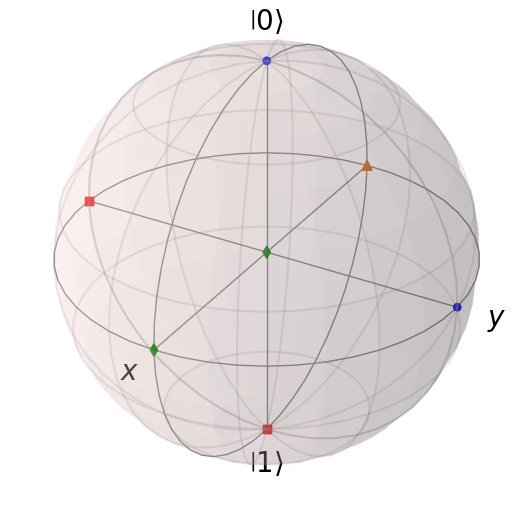

In [3]:

from qutip import Bloch

b = Bloch()

for name, psi in states.items():
    rho = psi if psi.isoper else qt.ket2dm(psi)
    r = bloch_from_dm(rho)
    b.add_points(r)

b.show()

In [4]:
import matplotlib.pyplot as plt

# 参数
omega_q = 2 * np.pi * 5.0  # GHz
H = -0.5 * omega_q * qt.sigmaz()

# 初态 |+>
psi0 = (qt.basis(2,0) + qt.basis(2,1)).unit()

# 时间：4个周期
T = 2 * np.pi / omega_q
tlist = np.linspace(0, 4*T, 200)

# 演化
result = qt.mesolve(
    H, psi0, tlist,
    [],
    [qt.sigmax(), qt.sigmay(), qt.sigmaz()]
)

rx, ry, rz = result.expect

/home/fanshaoze/.local/lib/python3.10/site-packages/qutip/solver/solver_base.py:584: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


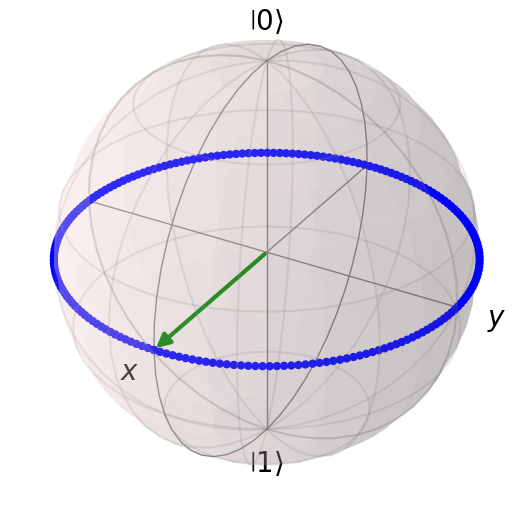

In [5]:
b = Bloch()

b.add_points([rx, ry, rz])  # trajectory
b.add_vectors(bloch_from_dm(qt.ket2dm(psi0)))  # 初始点

b.show()

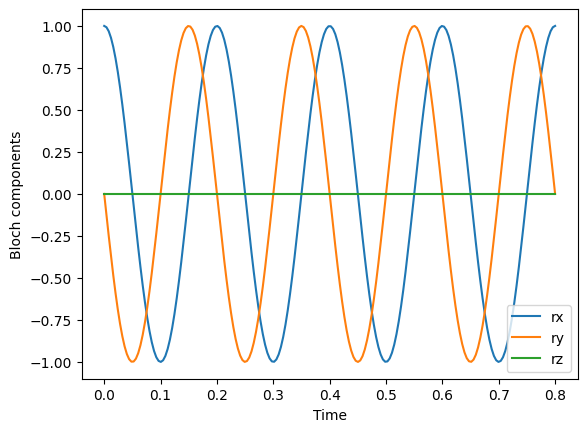

In [6]:
plt.figure()

plt.plot(tlist, rx, label="rx")
plt.plot(tlist, ry, label="ry")
plt.plot(tlist, rz, label="rz")

plt.xlabel("Time")
plt.ylabel("Bloch components")
plt.legend()
plt.show()